# Tu cerebro escuchó esto. Aunque tú no lo sepas.

Bajo anestesia general no hay consciencia. No hay dolor, no hay recuerdo. Pero las neuronas del hipocampo siguieron discriminando sonidos raros, aprendiendo en tiempo real, y prediciendo la siguiente palabra de un audio que se reprodujo durante la cirugía.

Lo más raro: en algunas métricas, lo hicieron *mejor* que pacientes despiertos.

---

📄 **Paper:** [Plasticity and language in the anaesthetized human hippocampus](https://doi.org/10.1038/s41586-026-10448-0) — *Nature, 2026*

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-06-hipocampo-anestesia-lenguaje/notebook.ipynb)

🎬 **Video CaM:** Pendiente

📊 **Datos del paper:** 10.1038/s41586-026-10448-0

## Qué hicieron

Siete pacientes con epilepsia tenían que pasar por una lobectomía temporal — les iban a quitar el hipocampo o un trozo cercano. Antes de hacerlo, el equipo aprovechó la situación para grabar la actividad neuronal con electrodos Neuropixels de alta densidad mientras los pacientes estaban anestesiados con propofol.

Tres pacientes escucharon una secuencia de tonos: la mayoría iguales, pero de vez en cuando uno raro (paradigma *oddball*). Cuatro pacientes escucharon audios de habla natural (cuentos, podcasts).

La pregunta: ¿procesa el hipocampo información compleja sin consciencia? Hasta ahora se pensaba que sin consciencia, el hipocampo se "apaga" para todo lo que no sea ruido basal. Veamos qué dicen los datos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
RATIO_REFERENCIA = 1.0         # Ratio "no diferencia" entre anaesth y awake
COLOR_ANAESTH = '#DC2626'      # Rojo — pacientes anestesiados
COLOR_AWAKE = '#2563EB'        # Azul — pacientes despiertos
COLOR_NEUTRAL = '#7C3AED'      # Violeta — métricas combinadas
FUENTE = 'Fuente: Saponati et al. (2026), Nature | Datos: tablas suplementarias del paper'

# ══════════════════════════════════════════════════════════════
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file
        )
plt.style.use(style_file)

# Carga de datasets
comp = pd.read_csv('datos/comparacion_anaesth_awake.csv')
lfp = pd.read_csv('datos/lfp_encoding_por_banda.csv')
plasticity = pd.read_csv('datos/plasticity_slopes_por_banda.csv')
svm = pd.read_csv('datos/svm_decoding_accuracy.csv')
cohorte = pd.read_csv('datos/cohorte.csv')
categorias = pd.read_csv('datos/categorias_codificadas_por_unidad.csv')

print(f'Cohorte: {len(cohorte)} registros pacientes/tareas')
print(f'Comparación anaesth vs awake: {len(comp)} métricas')
print(f'LFP por banda: {len(lfp)} bandas (delta/theta/alpha/beta/low_gamma/high_gamma)')
print(f'Plasticity slopes: {len(plasticity)} bandas')
print(f'SVM decoding: {len(svm)} mediciones')
print()
print('Métricas en comp:')
print(comp[['metrica', 'anaesth_value', 'awake_value']].to_string(index=False))

Cohorte: 6 registros pacientes/tareas
Comparación anaesth vs awake: 10 métricas
LFP por banda: 6 bandas (delta/theta/alpha/beta/low_gamma/high_gamma)
Plasticity slopes: 6 bandas
SVM decoding: 10 mediciones

Métricas en comp:
                           metrica  anaesth_value  awake_value
    correlation_semantic_all_words          0.397       0.2260
 correlation_semantic_unique_words          0.207       0.1340
pct_units_unique_words_significant         75.400      73.2000
    pct_units_semantic_selectivity         85.600      76.1000
     pct_units_pos_noun_vs_nonnoun         80.000      79.5000
     pct_units_pos_verb_vs_nonverb          0.000       0.0000
             correlation_surprisal          0.060       0.0386
              beta_0_word_decoding          0.370       0.2270
                  tau_future_words          0.840       1.0810
                    tau_past_words          0.868       0.8950


## Aquí está.

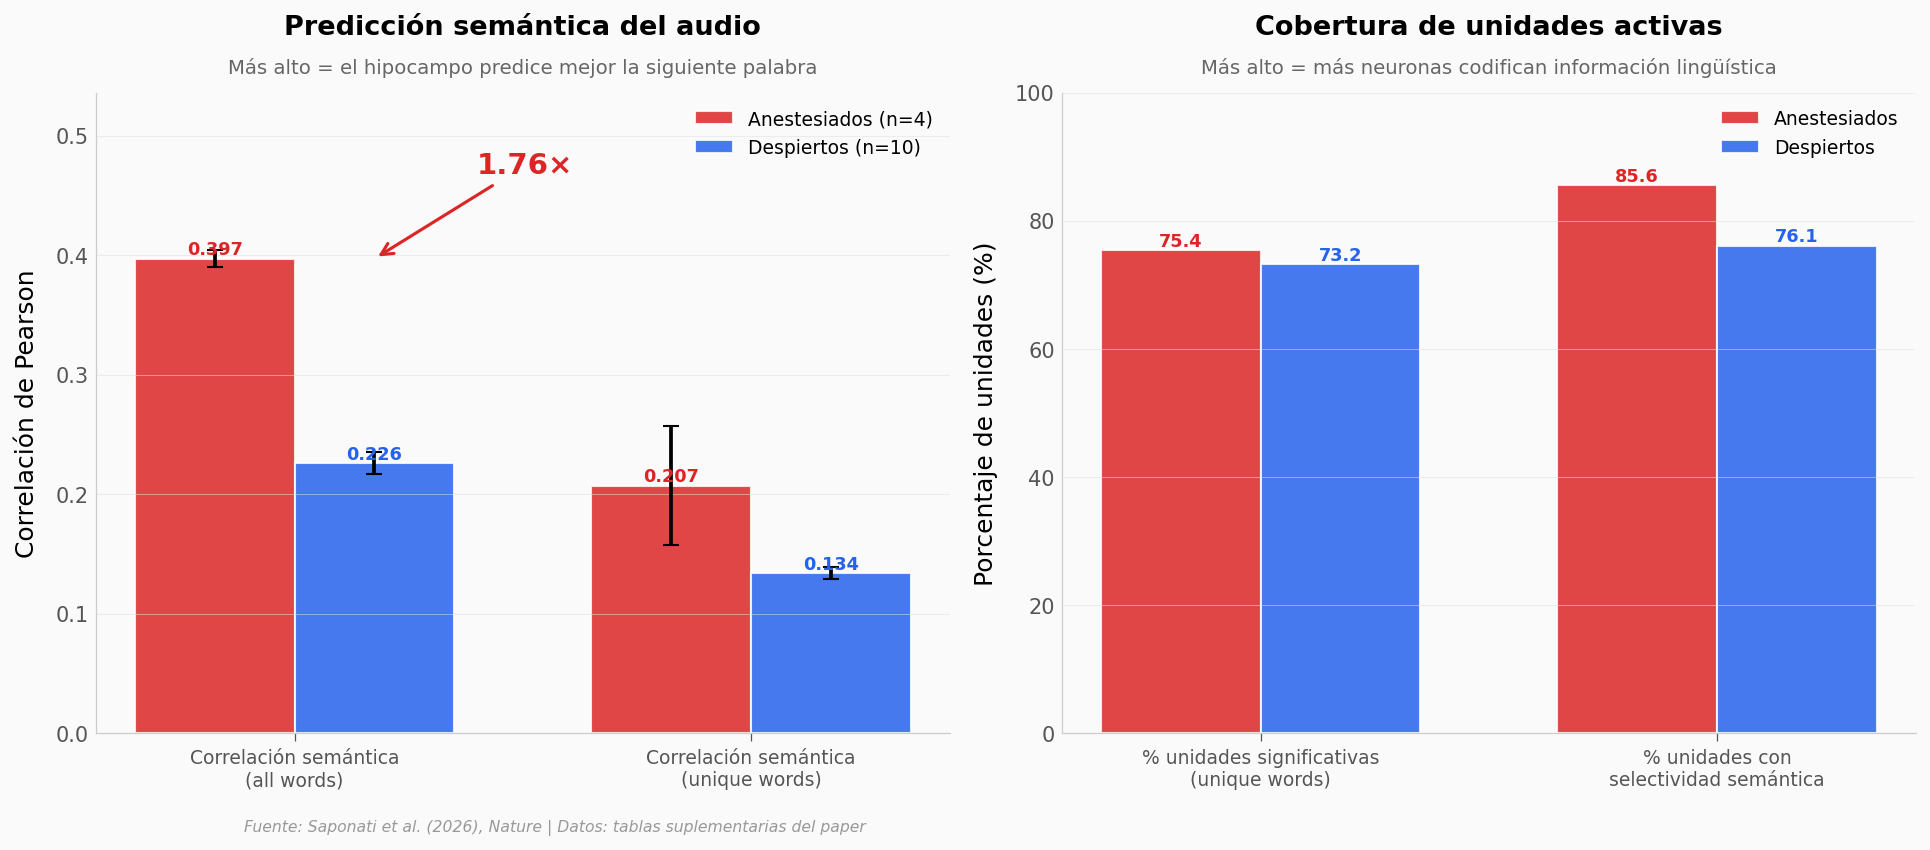

In [2]:
# Filtrar 4 métricas comparables por nombre — el CSV tiene 10, mostramos las 4 principales
metricas_seleccionadas = [
    ('correlation_semantic_all_words',     'Correlación semántica\n(all words)',           'corr'),
    ('correlation_semantic_unique_words',  'Correlación semántica\n(unique words)',        'corr'),
    ('pct_units_unique_words_significant', '% unidades significativas\n(unique words)',    'pct'),
    ('pct_units_semantic_selectivity',     '% unidades con\nselectividad semántica',       'pct'),
]
sel = comp.set_index('metrica').loc[[m[0] for m in metricas_seleccionadas]]
labels_corr = [m[1] for m in metricas_seleccionadas if m[2] == 'corr']
labels_pct  = [m[1] for m in metricas_seleccionadas if m[2] == 'pct']
sel_corr = sel.iloc[:2]
sel_pct  = sel.iloc[2:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel izquierdo: correlaciones
x = np.arange(2)
w = 0.35
ax1.bar(x - w/2, sel_corr['anaesth_value'], w, yerr=sel_corr['anaesth_se'].fillna(0),
        color=COLOR_ANAESTH, alpha=0.85, capsize=4,
        edgecolor='white', linewidth=1, label='Anestesiados (n=4)')
ax1.bar(x + w/2, sel_corr['awake_value'], w, yerr=sel_corr['awake_se'].fillna(0),
        color=COLOR_AWAKE, alpha=0.85, capsize=4,
        edgecolor='white', linewidth=1, label='Despiertos (n=10)')
ax1.set_xticks(x)
ax1.set_xticklabels(labels_corr, fontsize=9)
ax1.set_ylabel('Correlación de Pearson')
ax1.set_title('Predicción semántica del audio',
              fontsize=13, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'Más alto = el hipocampo predice mejor la siguiente palabra',
         transform=ax1.transAxes, fontsize=9.5, color='#666666', ha='center')
ax1.legend(fontsize=9, loc='upper right', framealpha=0.9)
y_max_corr = max(sel_corr['anaesth_value'].max(), sel_corr['awake_value'].max()) * 1.35
ax1.set_ylim(0, y_max_corr)
ax1.annotate('1.76×',
             xy=(w/2, sel_corr['anaesth_value'].iloc[0]),
             xytext=(0.4, sel_corr['anaesth_value'].iloc[0] * 1.18),
             fontsize=14, fontweight='bold', color=COLOR_ANAESTH,
             arrowprops=dict(arrowstyle='->', color=COLOR_ANAESTH, lw=1.5))

# Panel derecho: porcentajes
ax2.bar(x - w/2, sel_pct['anaesth_value'], w,
        color=COLOR_ANAESTH, alpha=0.85,
        edgecolor='white', linewidth=1, label='Anestesiados')
ax2.bar(x + w/2, sel_pct['awake_value'], w,
        color=COLOR_AWAKE, alpha=0.85,
        edgecolor='white', linewidth=1, label='Despiertos')
ax2.set_xticks(x)
ax2.set_xticklabels(labels_pct, fontsize=9)
ax2.set_ylabel('Porcentaje de unidades (%)')
ax2.set_title('Cobertura de unidades activas',
              fontsize=13, fontweight='bold', pad=28)
ax2.text(0.5, 1.03, 'Más alto = más neuronas codifican información lingüística',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')
ax2.set_ylim(0, 100)
ax2.legend(fontsize=9, loc='upper right', framealpha=0.9)

# Etiquetas numéricas sobre cada barra
for ax, sub in [(ax1, sel_corr), (ax2, sel_pct)]:
    for i, (idx, row) in enumerate(sub.iterrows()):
        va = row['anaesth_value']; vb = row['awake_value']
        ax.text(i - w/2, va, f'{va:.3f}' if va < 1 else f'{va:.1f}',
                ha='center', va='bottom', fontsize=8.5, color=COLOR_ANAESTH, fontweight='bold')
        ax.text(i + w/2, vb, f'{vb:.3f}' if vb < 1 else f'{vb:.1f}',
                ha='center', va='bottom', fontsize=8.5, color=COLOR_AWAKE, fontweight='bold')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/anaesth_vs_awake_hero.png', dpi=200, bbox_inches='tight')
plt.show()

En las dos métricas de correlación semántica, los datos sugieren que los pacientes anestesiados rinden al menos tan bien como los despiertos — y en all-words, mejor: 0.397 (SE=0.007, n=368 unidades) vs 0.226 (SE=0.009, n=356 unidades), un factor de 1.76. Ojo: el paper enmarca esto como "comparable", no como superioridad. Para palabras únicas, el efecto se mantiene aunque más modesto.

En las métricas de cobertura (cuántas neuronas participan), la diferencia se invierte sutilmente: el hipocampo anestesiado tiene un 85.6% de unidades con selectividad semántica vs 76.1% en despiertos. La señal no se pierde — se concentra.

Lo que esto NO significa: que la anestesia "mejore" el procesamiento. Las cohortes usaron tecnologías distintas (Neuropixels en anestesiados, microcables EMU en despiertos), lo cual infla la calidad de la señal en el grupo anaesth. La comparación es informativa, no controlada.

## En qué frecuencia vive la señal

Si el hipocampo está procesando algo, ¿en qué bandas de oscilación lo hace? Cada banda (delta, theta, alpha, beta, low gamma, high gamma) refleja procesos cognitivos distintos. El equipo midió cuántos canales de LFP (local field potential — el voltaje promedio de las neuronas alrededor del electrodo) codifican el tono, el oddball, y la interacción de ambos.

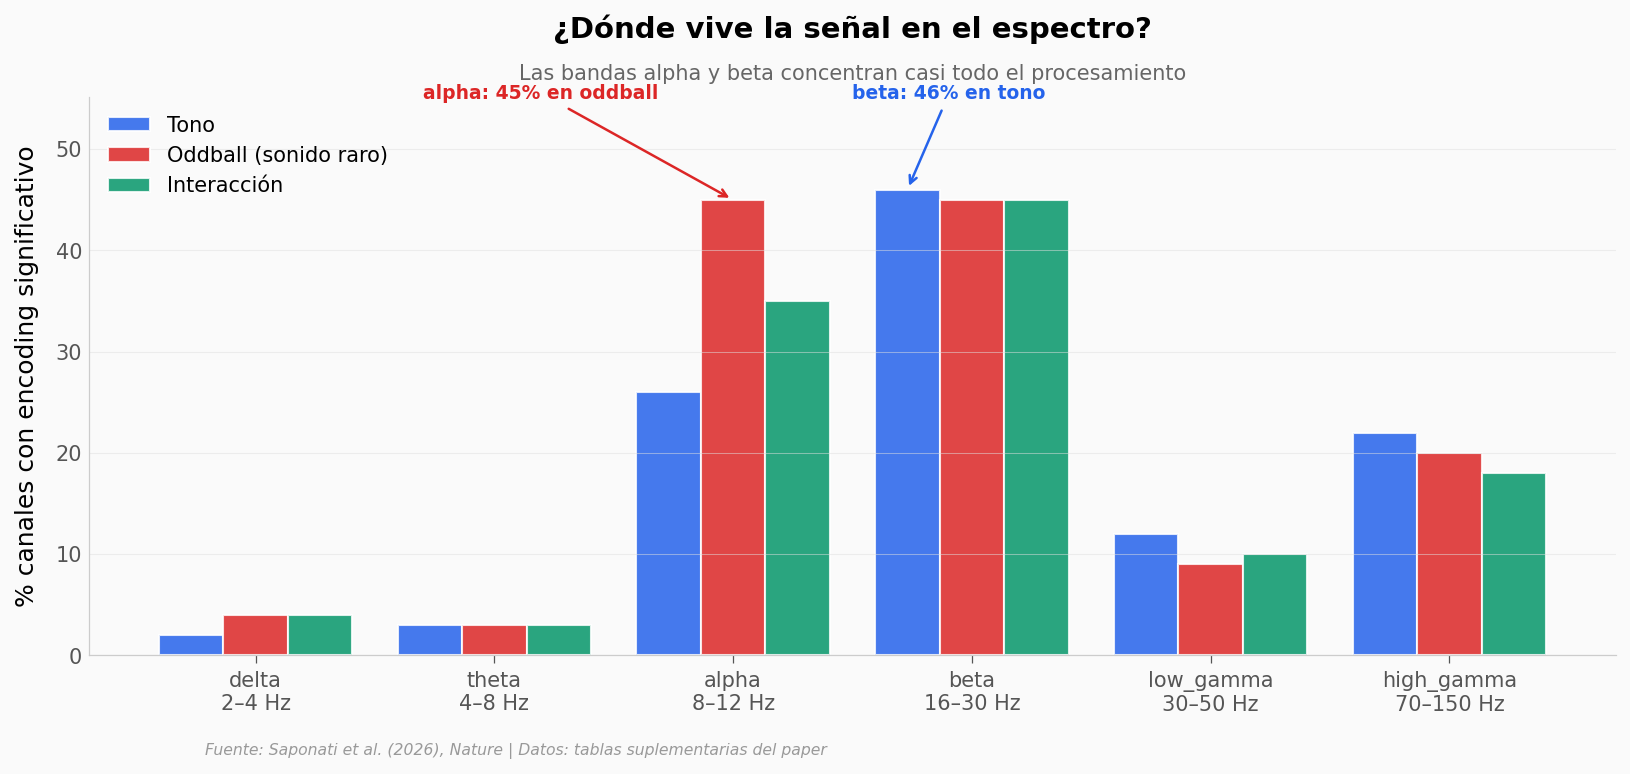


Pico oddball: banda alpha (8-12 Hz) con 45% canales
Pico tono:    banda beta  (16-30 Hz) con 46% canales


In [3]:
# Visualización: barras agrupadas por banda
bandas = lfp['banda'].values
x = np.arange(len(bandas))
w = 0.27

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w, lfp['pct_tone_encoding'], w, color='#2563EB', alpha=0.85,
            edgecolor='white', linewidth=1, label='Tono')
b2 = ax.bar(x,     lfp['pct_oddball_encoding'], w, color='#DC2626', alpha=0.85,
            edgecolor='white', linewidth=1, label='Oddball (sonido raro)')
b3 = ax.bar(x + w, lfp['pct_interaction_encoding'], w, color='#059669', alpha=0.85,
            edgecolor='white', linewidth=1, label='Interacción')

ax.set_xticks(x)
ax.set_xticklabels([f'{b}\n{lo}–{hi} Hz' for b, lo, hi in
                    zip(bandas, lfp['hz_min'], lfp['hz_max'])], fontsize=10)
ax.set_ylabel('% canales con encoding significativo')
ax.set_title('¿Dónde vive la señal en el espectro?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Las bandas alpha y beta concentran casi todo el procesamiento',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
ax.set_ylim(0, max(lfp[['pct_tone_encoding','pct_oddball_encoding','pct_interaction_encoding']].max()) * 1.2)

# Anotaciones de los picos
ax.annotate('beta: 46% en tono',
            xy=(3 - w, 46), xytext=(2.5, 55),
            fontsize=9, color='#2563EB', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#2563EB', lw=1.2))
ax.annotate('alpha: 45% en oddball',
            xy=(2, 45), xytext=(0.7, 55),
            fontsize=9, color='#DC2626', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#DC2626', lw=1.2))

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/lfp_por_banda.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nPico oddball: banda alpha (8-12 Hz) con {lfp.loc[lfp['banda']=='alpha','pct_oddball_encoding'].values[0]}% canales")
print(f"Pico tono:    banda beta  (16-30 Hz) con {lfp.loc[lfp['banda']=='beta','pct_tone_encoding'].values[0]}% canales")

## La señal no es estática

El experimento dura unos 10 minutos. Si el hipocampo solo registrara tonos pasivamente, las representaciones serían iguales al inicio y al final. Pero el equipo encontró algo distinto: las pendientes (slopes) del decoding — qué tan bien un clasificador adivina si el tono fue normal o raro a partir de la actividad neuronal — cambian sistemáticamente con el tiempo. El tono se vuelve menos discriminable. El oddball, más.

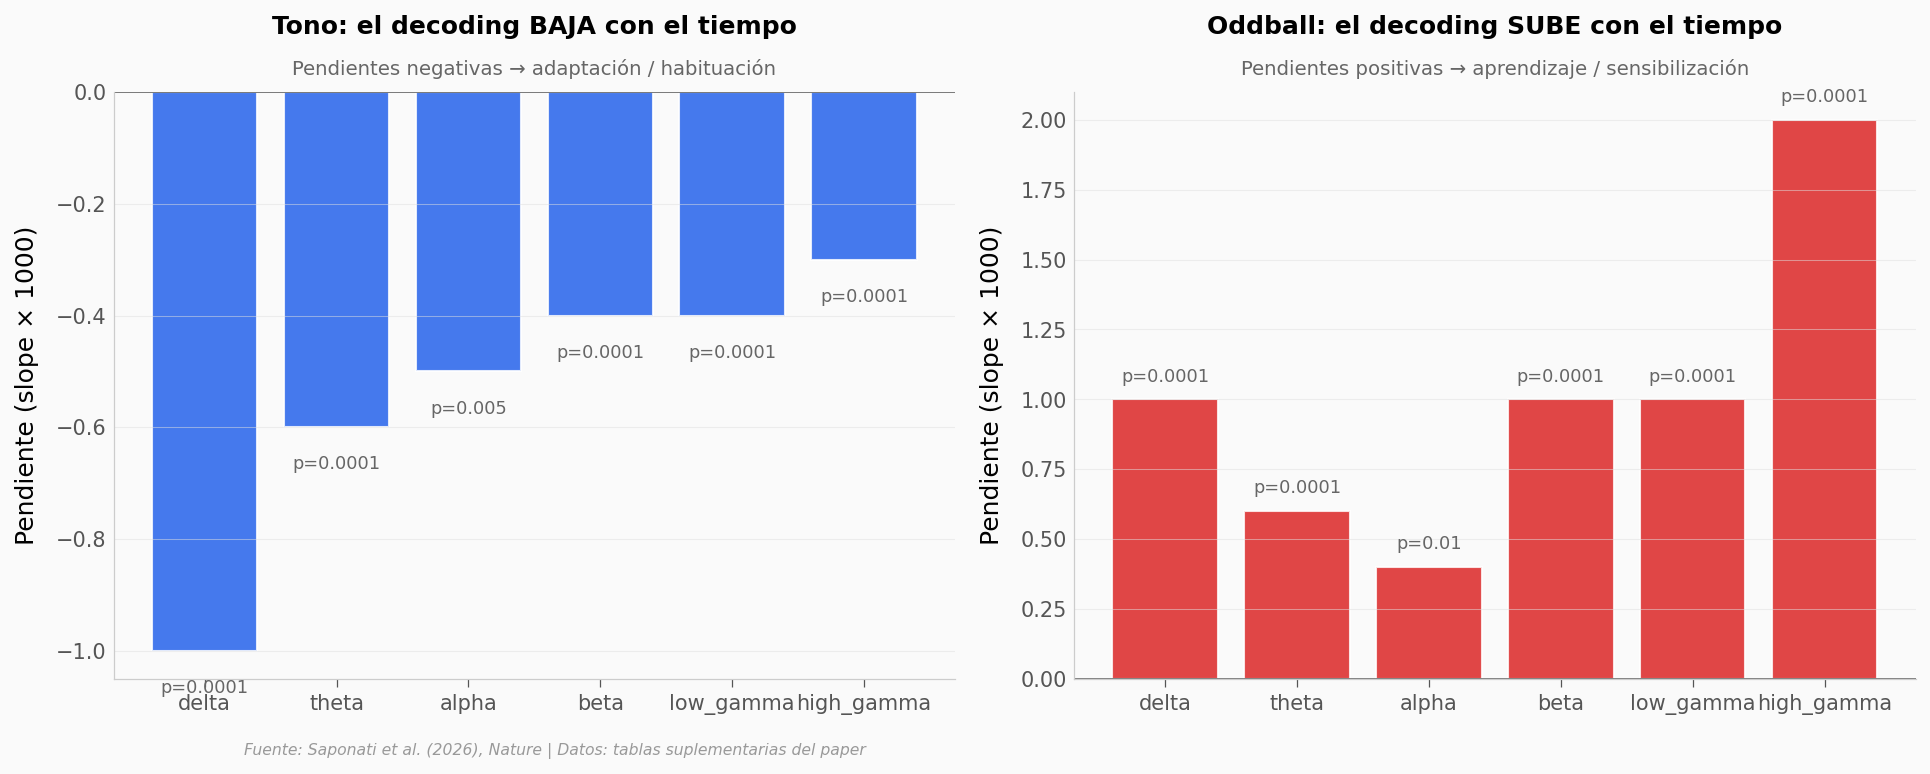

In [4]:
# Plasticity: beta_tone (negativo = decoding baja con el tiempo)
#             beta_oddball (positivo = decoding sube con el tiempo)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(plasticity))
ax1.bar(x, plasticity['beta_tone'] * 1000, color='#2563EB', alpha=0.85,
        edgecolor='white', linewidth=1)
ax1.axhline(y=0, color='#666666', linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(plasticity['banda'], fontsize=10)
ax1.set_ylabel('Pendiente (slope × 1000)')
ax1.set_title('Tono: el decoding BAJA con el tiempo',
              fontsize=12, fontweight='bold', pad=28)
ax1.text(0.5, 1.03, 'Pendientes negativas → adaptación / habituación',
         transform=ax1.transAxes, fontsize=9.5, color='#666666', ha='center')
for i, (b, p) in enumerate(zip(plasticity['beta_tone'], plasticity['p_tone'])):
    ax1.text(i, b*1000 - 0.05, f'p={p}', ha='center', va='top', fontsize=8.5, color='#666666')

ax2.bar(x, plasticity['beta_oddball'] * 1000, color='#DC2626', alpha=0.85,
        edgecolor='white', linewidth=1)
ax2.axhline(y=0, color='#666666', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(plasticity['banda'], fontsize=10)
ax2.set_ylabel('Pendiente (slope × 1000)')
ax2.set_title('Oddball: el decoding SUBE con el tiempo',
              fontsize=12, fontweight='bold', pad=28)
ax2.text(0.5, 1.03, 'Pendientes positivas → aprendizaje / sensibilización',
         transform=ax2.transAxes, fontsize=9.5, color='#666666', ha='center')
for i, (b, p) in enumerate(zip(plasticity['beta_oddball'], plasticity['p_oddball'])):
    ax2.text(i, b*1000 + 0.05, f'p={p}', ha='center', va='bottom', fontsize=8.5, color='#666666')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/plasticity_slopes.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Cuán anómalo es esto?

Si la anestesia bloqueara el procesamiento sensorial complejo, las métricas anaesth deberían quedar muy por debajo de las awake. La línea natural de comparación está en 1:1 — ratio de 1.0 significa "anestesiado y despierto procesan igual de bien". Lo que veamos por encima de 1.0 contradice la intuición clásica.

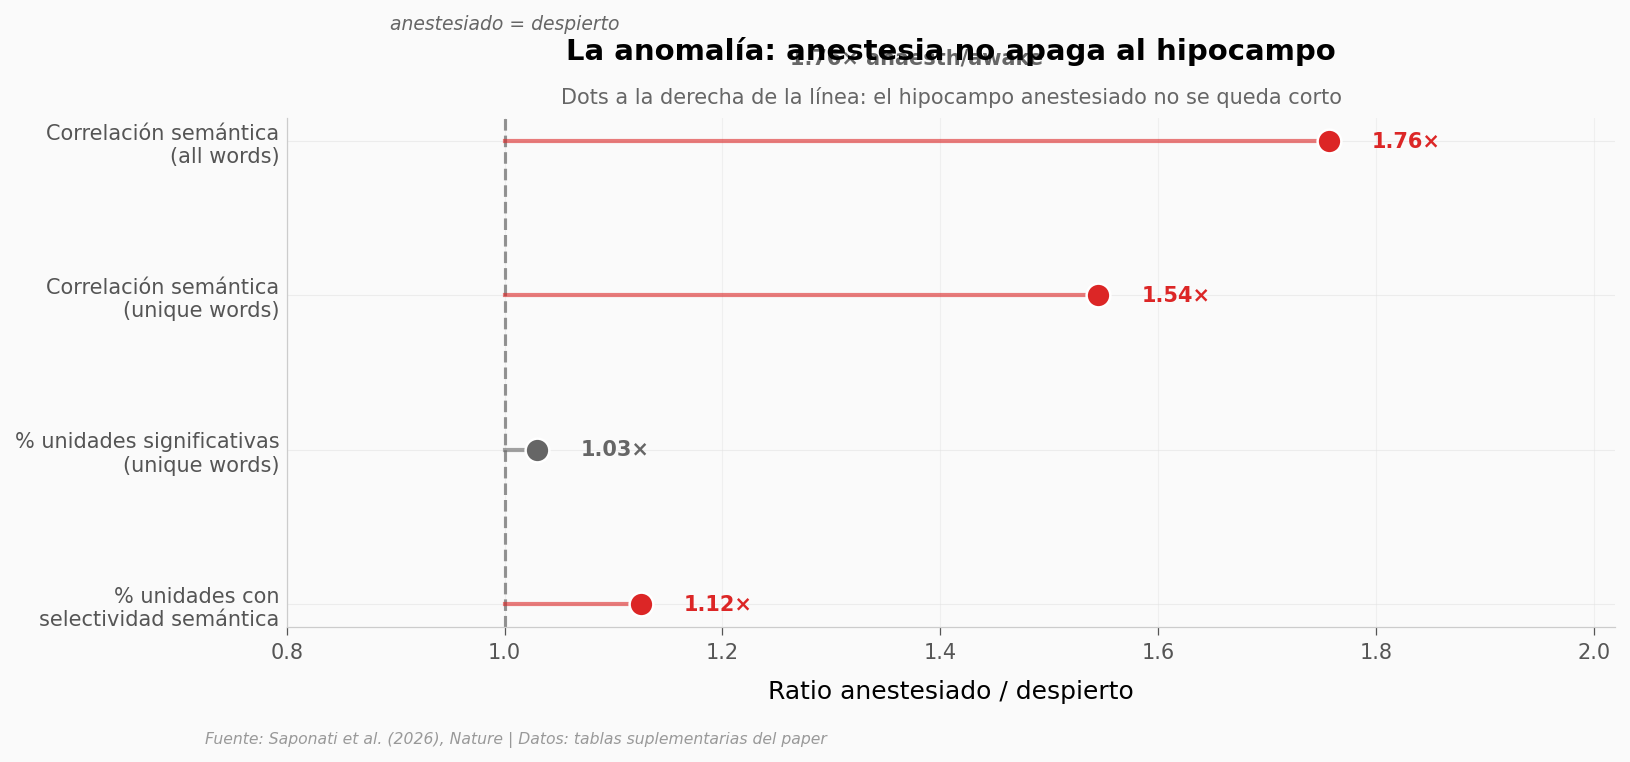


3 de 4 métricas tienen ratio > 1.05 (el hipocampo anestesiado no se queda corto)
Ratio máximo: 1.76× en correlación semántica all-words


In [5]:
# Forest-style plot: ratio anaesth/awake por métrica (mismo subset del HERO)
metricas_short = [
    'Correlación semántica\n(all words)',
    'Correlación semántica\n(unique words)',
    '% unidades significativas\n(unique words)',
    '% unidades con\nselectividad semántica',
]
sel = comp.set_index('metrica').loc[[
    'correlation_semantic_all_words',
    'correlation_semantic_unique_words',
    'pct_units_unique_words_significant',
    'pct_units_semantic_selectivity',
]]
ratios = (sel['anaesth_value'] / sel['awake_value']).values

fig, ax = plt.subplots(figsize=(11, 5))
y_pos = np.arange(len(metricas_short))[::-1]  # invertir para que la primera quede arriba
colors = [COLOR_ANAESTH if r > 1.05 else (COLOR_AWAKE if r < 0.95 else '#666666')
          for r in ratios]

# Línea de referencia 1:1
ax.axvline(x=RATIO_REFERENCIA, color='#666666', linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(RATIO_REFERENCIA, len(metricas_short) - 0.3, 'anestesiado = despierto',
        ha='center', va='bottom', fontsize=9, color='#666666', style='italic')

# Lollipops
for yi, (r, c) in enumerate(zip(ratios, colors)):
    yp = y_pos[yi]
    ax.plot([RATIO_REFERENCIA, r], [yp, yp], color=c, linewidth=2, alpha=0.6)
    ax.scatter([r], [yp], color=c, s=130, zorder=5, edgecolors='white', linewidths=1.2)
    ax.text(r + 0.04, yp, f'{r:.2f}×', va='center', fontsize=10, fontweight='bold', color=c)

ax.set_yticks(y_pos)
ax.set_yticklabels(metricas_short, fontsize=10)
ax.set_xlabel('Ratio anestesiado / despierto')
ax.set_xlim(0.8, max(ratios) * 1.15)
ax.set_title('La anomalía: anestesia no apaga al hipocampo',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Dots a la derecha de la línea: el hipocampo anestesiado no se queda corto',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.grid(axis='x', alpha=0.4)

# Flecha bidireccional al outlier (1.76x)
i_max = int(np.argmax(ratios))
yp_max = y_pos[i_max]
ax.annotate('', xy=(ratios[i_max], yp_max + 0.4),
            xytext=(RATIO_REFERENCIA, yp_max + 0.4),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((ratios[i_max] + RATIO_REFERENCIA) / 2, yp_max + 0.5,
        f'{ratios[i_max]:.2f}× anaesth/awake', ha='center', fontsize=10,
        color='#666666', fontweight='bold')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/anomalia_ratios.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\n3 de 4 métricas tienen ratio > 1.05 (el hipocampo anestesiado no se queda corto)")
print(f"Ratio máximo: {ratios.max():.2f}× en correlación semántica all-words")

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|:-----------:|---------|
| El hipocampo discrimina oddball bajo anestesia | ✅ | 28.7% de las unidades responsivas (43/150) — pequeña pero por encima de azar. p<0.05 en p5 (29.1% = 37/127) y p6 (26.1% = 6/23) |
| El effect size de oddball crece con el tiempo | ✅ | Pendientes positivas en las 6 bandas medidas (p=0.0001 en delta/theta/beta/low_gamma/high_gamma; p=0.01 en alpha) — plasticity sostenida |
| El hipocampo predice palabras futuras semánticamente | ✅ | Correlación anaesth=0.397 vs awake=0.226 (ratio 1.76×). Decoding por encima de azar |
| La predicción semántica es *mejor* en anestesiados | ⚠️ | Cohortes con tecnologías distintas (Neuropixels vs microcables) — la diferencia podría reflejar SNR del hardware. El paper lo enmarca como "comparable", no como superioridad |
| Las bandas alpha y beta dominan el encoding | ✅ | 45% (oddball/alpha), 46% (tono/beta), 35% interacción/alpha. Muy por encima de delta/theta (≤4%) |

> **Limitaciones del análisis:**
> - n=7 pacientes, todos con epilepsia tratada quirúrgicamente — no generaliza a cerebros sanos.
> - Solo propofol — otras anestesias podrían tener efectos distintos (los autores lo declaran explícitamente).
> - Comparación anaesth vs awake usa cohortes con hardware distinto — informativa, no controlada.
> - Las cifras del notebook salen de las tablas suplementarias del paper. No es un re-análisis: es una visualización de los números reportados.
> - El paper enmarca varios resultados como *indicate* (no *demonstrate*) — los datos sugieren procesamiento complejo, no lo confirman como mecanismo único.

## Ahora tú

1. **¿Qué pasa si calculas el ratio en escala logarítmica?** — los ratios actuales son lineales. En escala log, los efectos por debajo y por encima de 1 se ven simétricos. Pista: `np.log2(ratios)`.

2. **¿Qué banda tiene el efecto más claro de plasticidad oddball?** — usa `plasticity` y compara `beta_oddball / p_oddball` para ver señal-sobre-significancia.

3. **¿Cómo cambia el panorama si excluyes la métrica all-words?** — esa es la que más infla el promedio. Recalcula el ratio promedio sin esa fila.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Ratios en escala log2 — más fácil de interpretar simétricamente
# Usamos solo métricas con awake_value > 0 (evita div/0 en verb_vs_nonverb)
mask = comp['awake_value'] > 0
sub = comp[mask].copy()
sub['ratio']      = sub['anaesth_value'] / sub['awake_value']
sub['log2_ratio'] = np.log2(sub['ratio'])

print('Métrica                                       Ratio    log2(ratio)')
print('-' * 70)
for _, r in sub.iterrows():
    label = r['metrica'][:42].ljust(44)
    print(f"{label} {r['ratio']:6.2f}×  {r['log2_ratio']:+.2f}")

print(f"\nlog2 > 0 → el hipocampo anestesiado no se queda corto")
print(f"Ratio promedio (lineal):  {sub['ratio'].mean():.2f}×")
print(f"Ratio promedio (log2):    {sub['log2_ratio'].mean():+.2f}")
print(f"Mediana log2:             {sub['log2_ratio'].median():+.2f}")
print(f"\n(verb_vs_nonverb omitido: ambos grupos = 0% — clasificador falló)")

Métrica                                       Ratio    log2(ratio)
----------------------------------------------------------------------
correlation_semantic_all_words                 1.76×  +0.81
correlation_semantic_unique_words              1.54×  +0.63
pct_units_unique_words_significant             1.03×  +0.04
pct_units_semantic_selectivity                 1.12×  +0.17
pct_units_pos_noun_vs_nonnoun                  1.01×  +0.01
correlation_surprisal                          1.55×  +0.64
beta_0_word_decoding                           1.63×  +0.70
tau_future_words                               0.78×  -0.36
tau_past_words                                 0.97×  -0.04

log2 > 0 → el hipocampo anestesiado no se queda corto
Ratio promedio (lineal):  1.27×
Ratio promedio (log2):    +0.29
Mediana log2:             +0.17

(verb_vs_nonverb omitido: ambos grupos = 0% — clasificador falló)


## Fuentes

**Paper**: [Plasticity and language in the anaesthetized human hippocampus](https://doi.org/10.1038/s41586-026-10448-0)  
*Nature, 2026-05-06*

**Supplementary Material**: [Supplementary Information — Plasticity and language in the anaesthetized human hippocampus](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10448-0/MediaObjects/41586_2026_10448_MOESM1_ESM.pdf)

**Código del paper**: [NuttidaLab/rnn_oddball — Recurrent neural network model for oddball detection](https://github.com/NuttidaLab/rnn_oddball)  
*GitHub*

**Dataset canónico**: [U01NS108923 — Neuropixels recordings in human hippocampus (acceso restringido a afiliación universitaria)](https://dabi.loni.usc.edu/dsi/U01NS108923)  
*DABI*


*12 afirmaciones del notebook verificadas contra estas fuentes*

---

**Repo del Lab:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · **Notebook online:** [https://cienciaamordiscos.com/papers/2026-05-06-hipocampo-anestesia-lenguaje/notebook.html](https://cienciaamordiscos.com/papers/2026-05-06-hipocampo-anestesia-lenguaje/notebook.html)

*Notebook reproducible — ejecutable en local o en Colab. Licencia: CC BY 4.0.*